# Text Classification with a Feed-forward Neural Network and BOW features

## Introduction for Junior Developers
In this notebook, we'll build a **Feed-forward Neural Network (FFNN)** to classify news articles into four categories.

### Key Concepts:
1.  **Bag of Words (BOW)**: Representing text by counting how many times each word appears.
2.  **Tokens**: Breaking down a sentence into individual words.
3.  **Neural Network Topology**:
    *   **Input Layer**: Takes the BOW feature vector.
    *   **Hidden Layer**: Learns complex patterns.
    *   **Output Layer**: Predicts the probability of each news category.

### The Pipeline:
```mermaid
graph TD
    A[Raw Text Data] --> B[Tokenization]
    B --> C[Vocabulary Creation]
    C --> D[Feature Engineering: BOW]
    D --> E[Neural Network Training]
    E --> F[Evaluation/Prediction]
```


First, we will do some initialization.

In [6]:
import random
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

# enable tqdm in pandas (provides progress bars for map/apply functions)
tqdm.pandas()

# set to True to use the GPU (if there is one available)
# Using a GPU significantly speeds up neural network training!
use_gpu = True

# select device: 'cuda' for NVIDIA GPUs, 'cpu' as fallback
device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
print(f'device: {device.type}')

# random seed ensure reproducibility (you get the same results chaque time you run)
seed = 1234

# set random seed across all libraries
if seed is not None:
    print(f'random seed: {seed}')
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


device: cpu
random seed: 1234


We will be using the AG's News Topic Classification Dataset.
It is stored in two CSV files: `train.csv` and `test.csv`, as well as a `classes.txt` that stores the labels of the classes to predict.

First, we will load the training dataset using [pandas](https://pandas.pydata.org/) and take a quick look at how the data.

In [7]:
train_df = pd.read_csv('data/ag_news_csv/train.csv', header=None)
train_df.columns = ['class index', 'title', 'description']
train_df

,class index,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


The dataset consists of 120,000 examples, each consisting of a class index, a title, and a description.
The class labels are distributed in a separated file. We will add the labels to the dataset so that we can interpret the data more easily. Note that the label indexes are one-based, so we need to subtract one to retrieve them from the list.

In [8]:
labels = open('data/ag_news_csv/classes.txt').read().splitlines()
classes = train_df['class index'].map(lambda i: labels[i-1])
train_df.insert(1, 'class', classes)
train_df

,class index,class,title,description
0,3,Business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,Business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...,...
119995,1,World,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Sports,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Sports,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Sports,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


Let's inspect how balanced our examples are by using a bar plot.

<Axes: xlabel='class'>

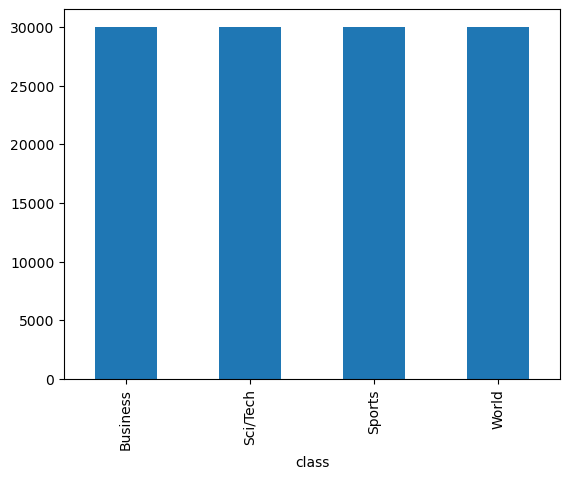

In [9]:
train_df['class'].value_counts().plot.bar()

The classes are evenly distributed. That's great!

However, the text contains some spurious backslashes in some parts of the text.
They are meant to represent newlines in the original text.
An example can be seen below, between the words "dwindling" and "band".

In [10]:
print(train_df.loc[0, 'description'])

Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


We will replace the backslashes with spaces on the whole column using pandas replace method.

In [11]:
train_df['text'] = train_df['title'].str.lower() + " " + train_df['description'].str.lower()
train_df['text'] = train_df['text'].str.replace('\\', ' ', regex=False)
train_df

,class index,class,title,description,text
0,3,Business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",wall st. bears claw back into the black (reute...
1,3,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,carlyle looks toward commercial aerospace (reu...
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,oil and economy cloud stocks' outlook (reuters...
3,3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,iraq halts oil exports from main southern pipe...
4,3,Business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","oil prices soar to all-time record, posing new..."
...,...,...,...,...,...
119995,1,World,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...,pakistan's musharraf says won't quit as army c...
119996,2,Sports,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...,renteria signing a top-shelf deal red sox gene...
119997,2,Sports,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...,saban not going to dolphins yet the miami dolp...
119998,2,Sports,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...,today's nfl games pittsburgh at ny giants time...


### Feature Engineering: Tokenization
Tokenization is the process of splitting text into small units (tokens), usually words.

```mermaid
graph LR
    A["'The stock market closed.'"] --> B[Tokenize]
    B --> C["['The', 'stock', 'market', 'closed', '.']"]
```


Now we will proceed to tokenize the title and description columns using NLTK's word_tokenize().
We will add a new column to our dataframe with the list of tokens.

In [12]:
import nltk
from nltk.tokenize import word_tokenize

for resource in ('punkt_tab', 'punkt'):
    nltk.download(resource, quiet=True)

train_df['tokens'] = train_df['text'].progress_map(word_tokenize)
train_df

100%|██████████| 120000/120000 [00:12<00:00, 9282.84it/s]


,class index,class,title,description,text,tokens
0,3,Business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",wall st. bears claw back into the black (reute...,"[wall, st., bears, claw, back, into, the, blac..."
1,3,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,carlyle looks toward commercial aerospace (reu...,"[carlyle, looks, toward, commercial, aerospace..."
2,3,Business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,oil and economy cloud stocks' outlook (reuters...,"[oil, and, economy, cloud, stocks, ', outlook,..."
3,3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,iraq halts oil exports from main southern pipe...,"[iraq, halts, oil, exports, from, main, southe..."
4,3,Business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","oil prices soar to all-time record, posing new...","[oil, prices, soar, to, all-time, record, ,, p..."
...,...,...,...,...,...,...
119995,1,World,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...,pakistan's musharraf says won't quit as army c...,"[pakistan, 's, musharraf, says, wo, n't, quit,..."
119996,2,Sports,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...,renteria signing a top-shelf deal red sox gene...,"[renteria, signing, a, top-shelf, deal, red, s..."
119997,2,Sports,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...,saban not going to dolphins yet the miami dolp...,"[saban, not, going, to, dolphins, yet, the, mi..."
119998,2,Sports,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...,today's nfl games pittsburgh at ny giants time...,"[today, 's, nfl, games, pittsburgh, at, ny, gi..."


The `dev_df` DataFrame in this notebook represents the **Development Set** (also known as the **Validation Set**).

Its primary purpose is to evaluate the model's performance on unseen data *during* the training process. This helps you:

1.  **Monitor Overfitting**: By comparing the performance on the training data (`train_df`) versus the development data (`dev_df`), you can see if the model is just memorizing the training examples or actually learning to generalize.
2.  **Hyperparameter Tuning**: It is used to decide when to stop training or how to adjust settings (like learning rate or hidden layer size) without "peeking" at the final test set.

### Where it appears in the code:

*   **Creation**: In Cell 12, it is created by splitting the original `train_df` using `train_test_split`, taking 20% of the data.
*   **Feature Engineering**: In Cell 14, common features are generated for it using the vocabulary learned only from the training set.
*   **Evaluation Loop**: In Cell 20, after every training epoch, the model is set to `model.eval()` mode to calculate the loss and accuracy on `dev_df`.

In [13]:
from sklearn.model_selection import train_test_split

train_df, dev_df = train_test_split(
    train_df,
    train_size=0.8,
    random_state=seed,
    stratify=train_df['class index'],
)
train_df.reset_index(drop=True, inplace=True)
dev_df.reset_index(drop=True, inplace=True)

print(f'train rows: {len(train_df.index):,}')
print(f'dev rows: {len(dev_df.index):,}')

train rows: 96,000
dev rows: 24,000


Now we will create a vocabulary from the training data. We will only keep the terms that repeat beyond some threshold established below.

In this notebook, **tokens** are the fundamental units used to represent text for the Neural Network. Instead of feeding the model entire sentences (which computers don't understand directly), we break the text down into individual words or punctuation marks.

### How they are used in the pipeline:

1.  **Breaking Down Text**: In Cell 11, the titles and descriptions are converted into lists of tokens (words) using NLTK's `word_tokenize` function.
2.  **Vocabulary Creation**: In Cell 13, the code analyzes all the tokens in the training set to find which words appear most frequently (using a `threshold` of 10). This becomes the model's "dictionary."
3.  **Feature Engineering (Bag of Words)**: In Cell 14, the lists of tokens are converted into numerical "feature vectors." Each vector counts how many times each word from the vocabulary appears in a specific news article.

Essentially, tokens bridge the gap between human language and the mathematical operations performed by the Neural Network.

In [14]:
threshold = 10
tokens = train_df['tokens'].explode().value_counts()
tokens = tokens[tokens > threshold]
id_to_token = ['[UNK]'] + tokens.index.tolist()
token_to_id = {w:i for i,w in enumerate(id_to_token)}
vocabulary_size = len(id_to_token)
print(f'vocabulary size: {vocabulary_size:,}')

vocabulary size: 17,430


The **Bag of Words (BOW)** feature vector used in this notebook and **Modern LLM Embeddings** (like those from GPT-4 or BERT) represent text in fundamentally different ways.

Here is a comparison:

| Feature | Bag of Words (This Notebook) | Modern LLM Embeddings |
| :--- | :--- | :--- |
| **Type** | Sparse, High-Dimensional | Dense, Low-Dimensional |
| **Meaning** | **Count-based**: Represents "is the word present and how often?" | **Semantic**: Represents "what does this text mean?" |
| **Context** | **Context-blind**: "Bank" (river) and "Bank" (finance) look the same. | **Context-aware**: Changes based on surrounding words. |
| **Word Order** | **Ignores order**: "Man bites dog" = "Dog bites man". | **Preserves order**: Understands sequence and grammar. |
| **Size** | Vocabulary size (e.g., 20,000+ dimensions). | Fixed size (e.g., 768 or 1536 dimensions). |
| **Values** | Integers (counts). | Floating-point numbers (abstract coordinates). |

### Comparison Diagram

```mermaid
graph LR
    subgraph BOW_Vector_Sparse
    B[0, 1, 0, 0, 3, 0, 0, 1, ...]
    end
    subgraph LLM_Embedding_Dense
    L[0.12, -0.45, 0.89, -0.01, ...]
    end
    B -- "Maps to exact vocabulary index" --> Words
    L -- "Maps to conceptual space" --> Meaning
```

### Why use one over the other?
*   **Use BOW** when you have limited compute power, a simple classification task, or when specific keywords are the most important signal (like detecting "spam" based on the word "$$$").
*   **Use LLM Embeddings** when you need to understand nuance, synonyms, or relationships between concepts (e.g., knowing that "puppy" and "dog" are related even though they are different words).

In [15]:
from collections import defaultdict

def make_feature_vector(tokens, unk_id=0):
    vector = defaultdict(int)
    for t in tokens:
        i = token_to_id.get(t, unk_id)
        vector[i] += 1
    return vector

train_df['features'] = train_df['tokens'].progress_map(make_feature_vector)
dev_df['features'] = dev_df['tokens'].progress_map(make_feature_vector)
train_df

100%|██████████| 24000/24000 [00:00<00:00, 95947.11it/s]


,class index,class,title,description,text,tokens,features
0,4,Sci/Tech,"China shuts 1,600 cybercafes","A furious China has shut down over 1,600 Inter...","china shuts 1,600 cybercafes a furious china h...","[china, shuts, 1,600, cybercafes, a, furious, ...","{126: 2, 6129: 1, 8698: 2, 0: 2, 5: 2, 6745: 1..."
1,3,Business,CME shares at new peak as earnings estimates rise,Shares in Chicago Mercantile Exchange Holdings...,cme shares at new peak as earnings estimates r...,"[cme, shares, at, new, peak, as, earnings, est...","{0: 2, 197: 2, 22: 1, 26: 1, 3975: 1, 21: 2, 2..."
2,1,World,British soldier charged with murdering Iraqi,A British soldier appeared in court today char...,british soldier charged with murdering iraqi a...,"[british, soldier, charged, with, murdering, i...","{191: 2, 1432: 2, 819: 2, 19: 2, 7762: 1, 213:..."
3,3,Business,Wal-Mart Keeps Same-Store Sales Outlook,"Wal-Mart Stores Inc. (WMT.N: Quote, Profile, R...",wal-mart keeps same-store sales outlook wal-ma...,"[wal-mart, keeps, same-store, sales, outlook, ...","{1040: 2, 1872: 1, 5535: 1, 130: 2, 732: 1, 62..."
4,1,World,Milosevic Calls for Control Over Own Trial Def...,Reuters - Former Yugoslav President Slobodan\M...,milosevic calls for control over own trial def...,"[milosevic, calls, for, control, over, own, tr...","{3625: 2, 647: 1, 11: 1, 640: 1, 45: 1, 591: 1..."
...,...,...,...,...,...,...,...
95995,2,Sports,North Texas star running back Patrick Cobbs ou...,"DENTON, Texas North Texas has shut down star r...",north texas star running back patrick cobbs ou...,"[north, texas, star, running, back, patrick, c...","{266: 2, 617: 3, 620: 2, 601: 2, 120: 2, 3785:..."
95996,2,Sports,NFL Insider,Six wins in a row have lifted the Green Bay Pa...,nfl insider six wins in a row have lifted the ...,"[nfl, insider, six, wins, in, a, row, have, li...","{714: 1, 7746: 1, 362: 1, 398: 1, 7: 1, 5: 1, ..."
95997,1,World,Groups Seek to Address Voting Troubles (AP),AP - Despite President Bush's clear margin of ...,groups seek to address voting troubles (ap) ap...,"[groups, seek, to, address, voting, troubles, ...","{971: 1, 1201: 1, 4: 1, 2515: 1, 1532: 2, 7266..."
95998,1,World,The Palestinian hunger strike ends,ighteen days after they began a hunger strike ...,the palestinian hunger strike ends ighteen day...,"[the, palestinian, hunger, strike, ends, ighte...","{1: 1, 303: 2, 4517: 2, 505: 2, 1314: 1, 0: 1,..."


In [16]:
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, index):
        x = torch.zeros(vocabulary_size, dtype=torch.float32)
        y = torch.tensor(self.y[index])
        for k,v in self.x[index].items():
            x[k] = v
        return x, y

In PyTorch, the `MyDataset` class is a **Data Wrapper** that acts as a bridge between your raw data (a pandas DataFrame/dictionary) and the Neural Network.

Its primary purpose is to **standardize how data is accessed** during training.

### What each part does:

1.  **`__init__`**: Receives and stores your features (BoW counts) and targets (class labels).
2.  **`__len__`**: Simply returns the total number of examples, so the training loop knows when an "epoch" (one full pass through the data) is finished.
3.  **`__getitem__` (The most important part)**: This is called every time the model needs an example. In this specific notebook, it performs **On-the-fly Transformation**:
    *   It takes the "sparse" dictionary of word counts (e.g., `{word_id_5: 2, word_id_10: 1}`).
    *   It converts it into a "dense" PyTorch **Tensor** of size `vocabulary_size`.
    *   This conversion happens right before the data is fed into the model, which saves a massive amount of memory (you don't have to store millions of zeros in RAM).

### Why use it?
By using this class, you can then use a DataLoader, which automatically handles:
*   **Batching**: Grouping 500 examples together.
*   **Shuffling**: Randomizing the order of data so the model doesn't "cheat" by learning sequences.
*   **Parallel Loading**: Using multiple CPU cores to prepare the next batch while the GPU is still training on the current one.

In [17]:
from torch import nn
import torch.nn.functional as F

# The Model class defines our Neural Network structure
class Model(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        # nn.Sequential chains layers together
        self.layers = nn.Sequential(
            # Dropout randomly 'turns off' neurons to prevent overfitting
            nn.Dropout(dropout),
            
            # Linear Layer 1: Input -> Hidden
            nn.Linear(input_dim, hidden_dim),
            
            # ReLU (Rectified Linear Unit) is our activation function
            # It adds non-linearity, allowing the network to learn complex patterns
            nn.ReLU(),
            
            # Another dropout layer for regularization
            nn.Dropout(dropout),
            
            # Linear Layer 2: Hidden -> Output (Final class prediction)
            nn.Linear(hidden_dim, output_dim),
        )
        
    def forward(self, x):
        # The forward method defines how data flows through the network
        return self.layers(x)


This cell defines the **Architecture** (the brain) of your model. It uses a **Feed-forward Neural Network** (also called a Multi-Layer Perceptron), which is the most fundamental type of deep learning model.

Think of this like a factory assembly line where data enters at one end, gets transformed in the middle, and a prediction comes out the other.

### Breakdown of the components:

1.  **`nn.Linear(input_dim, hidden_dim)` (The Hidden Layer)**:
    *   This is where the learning happens. It takes your massive Bag of Words vector (the "Input") and compresses it into a smaller, more meaningful representation (the "Hidden" space). 
    *   It's essentially doing a complex version of $y = mx + b$ for every single feature.

2.  **`nn.ReLU()` (The Spark)**:
    *   This stands for "Rectified Linear Unit." Without this, your model is just a simple linear regression. 
    *   ReLU acts like a filter: it keeps positive signals and blocks negative ones. This "non-linearity" is what allows neural networks to learn complex patterns instead of just straight lines.

3.  **`nn.Dropout(dropout)` (The Generalizer)**:
    *   This is a "regularization" technique. During training, it randomly "turns off" some neurons.
    *   **Why?** It prevents the model from becoming lazy and over-relying on a specific word (like "the") to make its prediction. It forces the model to look at the whole context.

4.  **`nn.Linear(hidden_dim, output_dim)` (The Output Layer)**:
    *   This finally converts those hidden patterns into 4 numbers—one for each of our news categories (World, Sports, Business, Sci/Tech). The highest number is our predicted class.

5.  **`forward(self, x)`**:
    *   This is the "instruction manual" for the data. Whenever you call `model(data)`, this function tells the data to flow through the layers in the exact order we defined them.

### The Flow:
[BoW Vector] $\rightarrow$ **Linear** $\rightarrow$ **ReLU** $\rightarrow$ **Dropout** $\rightarrow$ **Linear** $\rightarrow$ [Class Scores]

### Understanding the Architecture
Our model is a Simple Feed-Forward Neural Network:

```mermaid
graph LR
    subgraph Input
    I[BOW Vector]
    end
    subgraph Hidden_Layer
    L1[Linear + ReLU]
    end
    subgraph Output
    L2[Linear]
    end
    I --> L1
    L1 --> L2
    L2 --> P[4 Category Scores]
```
*   **Linear Layers**: Perform matrix multiplication ($y = xW^T + b$).
*   **ReLU**: The standard choice for "sparking" hidden neurons into life.
*   **Dropout**: Helps the model generalize by making it not overly dependent on specific words.


In [18]:
from torch import optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

# hyperparameters: These are the "knobs" we turn to tune the model
lr = 1e-3            # Learning rate: How fast the model adjusts its weights
weight_decay = 1e-5  # L2 regularization: Prevents weights from becoming too large
batch_size = 500     # Number of examples processed at once
shuffle = True       # Mix the data to ensure the model doesn't learn the order
n_epochs = 5         # Number of times the model sees the entire dataset
input_dim = vocabulary_size
hidden_dim = 50      # Size of the hidden layer (internal representation)
output_dim = len(labels) # 4 output units (one for each category)
dropout = 0.3        # Probability of dropping a neuron

# initialize the model, loss function, optimizer, and data-loader
model = Model(input_dim, hidden_dim, output_dim, dropout).to(device)

# CrossEntropyLoss is standard for multi-class classification
loss_func = nn.CrossEntropyLoss()

# Adam is a popular optimizer that adjusts learning rates automatically
optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay)

# DataLoaders handle batching and shuffling for us
train_ds = MyDataset(
    train_df['features'],
    train_df['class index'] - 1)
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=shuffle)

dev_ds = MyDataset(
    dev_df['features'],
    dev_df['class index'] - 1)
dev_dl = DataLoader(
    dev_ds,
    batch_size=batch_size,
    shuffle=shuffle)

# lists used to store plotting data
train_loss, train_acc = [], []
dev_loss, dev_acc = [], []


This cell is the **Configuration Hub** where the model and its training environment are initialized. It prepares the "engine" (the model), the "fuel" (the data), and the "mechanics" (the optimizer) before the training process begins.

### 1. The Hyperparameters ("The Knobs")
These are variables you set manually to control how the model learns:
*   **`lr = 1e-3` (Learning Rate)**: How large the steps are when the model adjusts its weights. Too high, and it might miss the solution; too low, and it will take forever to learn.
*   **`batch_size = 500`**: Instead of looking at 120,000 articles one by one, the model looks at 500 at a time. This is much faster and more stable.
*   **`n_epochs = 5`**: The model will see the entire training dataset 5 times.

### 2. The Core Components
*   **`model`**: Actual initialization of the `Model` class you defined earlier. It is moved `.to(device)` (either your GPU or CPU).
*   **`loss_func` (CrossEntropyLoss)**: The "grading system." It calculates how far the model's prediction is from the truth. Lower loss means better predictions.
*   **`optimizer` (Adam)**: The "brain" that adjusts the model's weights based on the loss. Adam is a very popular choice because it automatically tunes itself as training progresses.

### 3. Data Preparation
*   **`MyDataset` & `DataLoader`**: These wrap your training and validation data (the features and class indices).
*   **`shuffle=True`**: This ensures the model doesn't accidentally learn the order of the news articles, which is a common pitfall in training.

### 4. Progress Tracking
*   **`train_loss`, `train_acc`, etc.**: These empty lists will store the performance statistics for every epoch so you can plot them later to see if your model is actually getting smarter.

### The Training Loop
Training is an iterative process:
```mermaid
graph TD
    A[Start Epoch] --> B[Get Data Batch]
    B --> C[Prediction]
    C --> D[Calculate Loss]
    D --> E[Backpropagation]
    E --> F[Update Weights]
    F --> G{More Batches?}
    G -- Yes --> B
    G -- No --> H[End Epoch]
```
During each step, the **Optimizer** updates the model's weights to minimize the **Loss Function** (error).


In [19]:
# train the model
for epoch in range(n_epochs):
    losses, acc = [], []
    # set model to training mode
    model.train()
    for X, y_true in tqdm(train_dl, desc=f'epoch {epoch+1} (train)'):
        # clear gradients
        model.zero_grad()
        # send batch to right device
        X = X.to(device)
        y_true = y_true.to(device)
        # predict label scores
        y_pred = model(X)
        # compute loss
        loss = loss_func(y_pred, y_true)
        # compute accuracy
        gold = y_true.detach().cpu().numpy()
        pred = np.argmax(y_pred.detach().cpu().numpy(), axis=1)
        # accumulate for plotting
        losses.append(loss.detach().cpu().item())
        acc.append(accuracy_score(gold, pred))
        # backpropagate
        loss.backward()
        # optimize model parameters
        optimizer.step()
    # save epoch stats
    train_loss.append(np.mean(losses))
    train_acc.append(np.mean(acc))
    
    # set model to evaluation mode
    model.eval()
    # disable gradient calculation
    with torch.no_grad():
        losses, acc = [], []
        for X, y_true in tqdm(dev_dl, desc=f'epoch {epoch+1} (dev)'):
            # send batch to right device
            X = X.to(device)
            y_true = y_true.to(device)
            # predict label scores
            y_pred = model(X)
            # compute loss
            loss = loss_func(y_pred, y_true)
            # compute accuracy
            gold = y_true.cpu().numpy()
            pred = np.argmax(y_pred.cpu().numpy(), axis=1)
            # accumulate for plotting
            losses.append(loss.cpu().item())
            acc.append(accuracy_score(gold, pred))
        # save epoch stats
        dev_loss.append(np.mean(losses))
        dev_acc.append(np.mean(acc))

epoch 5 (dev): 100%|██████████| 48/48 [00:03<00:00, 14.95it/s]


Cell 33 contains the **Core Training Loop**. This is where the model actually learns from the data by iteratively adjusting its weights to minimize errors.

Here is a breakdown of what happens in this cell:

### 1. The Training Phase
For each epoch (one full pass through the dataset), the model enters a loop where it:
*   **Sets mode to `model.train()`**: This activates features like **Dropout**, which are only used during training to prevent the model from over-relying on specific words.
*   **Zeroes Gradients**: Clears old calculations so they don't interfere with the new batch.
*   **Forward Pass**: Passes the input data `X` through the network to get predictions `y_pred`.
*   **Calculates Loss**: Uses the "grading system" (`loss_func`) to see how far the predictions are from the actual labels.
*   **Backpropagation (`loss.backward()`)**: Calculates exactly how much each weight in the network contributed to the error.
*   **Optimization (`optimizer.step()`)**: Updates the weights to slightly reduce the error for the next time.

### 2. The Evaluation Phase (Dev Set)
After every training epoch, the model is tested on the **Development Set** to see how well it generalizes to data it hasn't "learned" from:
*   **Sets mode to `model.eval()`**: Deactivates Dropout to get the model's true, stable predictions.
*   **`torch.no_grad()`**: Disables gradient tracking to save memory and speed up computation, as we aren't updating weights here.
*   **Calculates Accuracy**: Compares the predicted categories against the true labels to give you a percentage score.

### 3. Statistics Tracking
The results (`losses` and `acc`) are averaged and stored in lists (`train_loss`, `dev_acc`, etc.). This allows you to visualize the learning progress in the subsequent cells, helping you identify if the model is **Overfitting** (getting better at training but worse at dev).

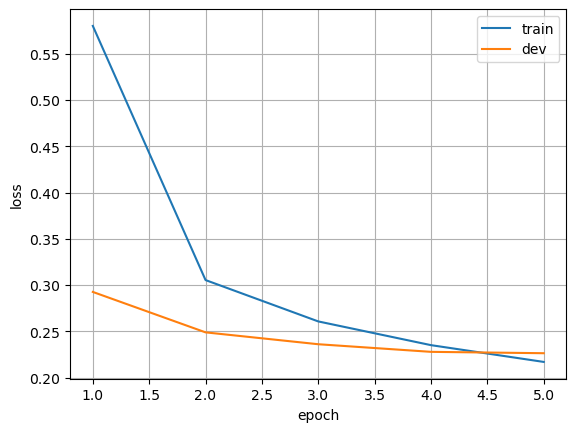

In [20]:
import matplotlib.pyplot as plt

x = np.arange(n_epochs) + 1

plt.plot(x, train_loss)
plt.plot(x, dev_loss)
plt.legend(['train', 'dev'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

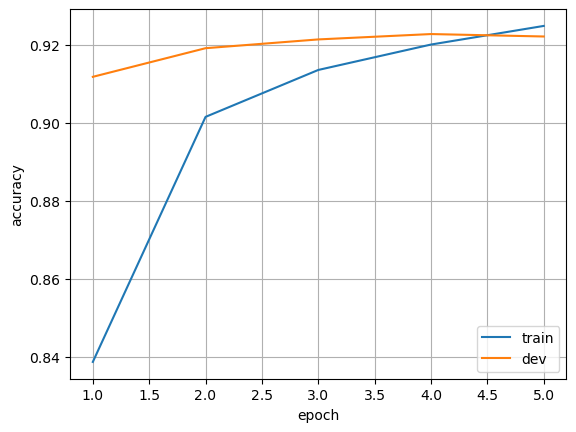

In [21]:
plt.plot(x, train_acc)
plt.plot(x, dev_acc)
plt.legend(['train', 'dev'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid(True)

## Evaluate on test dataset

In [22]:
# repeat all preprocessing done above, this time on the test set
test_df = pd.read_csv('data/ag_news_csv/test.csv', header=None)
test_df.columns = ['class index', 'title', 'description']
test_df['text'] = test_df['title'].str.lower() + " " + test_df['description'].str.lower()
test_df['text'] = test_df['text'].str.replace('\\', ' ', regex=False)
test_df['tokens'] = test_df['text'].progress_map(word_tokenize)
test_df['features'] = test_df['tokens'].progress_map(make_feature_vector)
test_df

100%|██████████| 7600/7600 [00:00<00:00, 98783.40it/s]


,class index,title,description,text,tokens,features
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...,fears for t n pension after talks unions repre...,"[fears, for, t, n, pension, after, talks, unio...","{865: 1, 11: 1, 147: 1, 5129: 1, 1469: 1, 38: ..."
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",the race is on: second private team sets launc...,"[the, race, is, on, :, second, private, team, ...","{1: 3, 490: 1, 24: 1, 10: 1, 28: 1, 133: 2, 91..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,ky. company wins grant to study peptides (ap) ...,"[ky., company, wins, grant, to, study, peptide...","{11325: 1, 60: 2, 398: 1, 4387: 2, 4: 2, 497: ..."
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,prediction unit helps forecast wildfires (ap) ...,"[prediction, unit, helps, forecast, wildfires,...","{10085: 1, 612: 1, 2052: 1, 735: 1, 0: 4, 14: ..."
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,calif. aims to limit farm-related smog (ap) ap...,"[calif., aims, to, limit, farm-related, smog, ...","{1064: 1, 1665: 1, 4: 2, 3240: 1, 0: 4, 14173:..."
...,...,...,...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...,around the world ukrainian presidential candid...,"[around, the, world, ukrainian, presidential, ...","{436: 1, 1: 2, 58: 1, 4554: 1, 389: 1, 1359: 1..."
7596,2,Void is filled with Clement,With the supply of attractive pitching options...,void is filled with clement with the supply of...,"[void, is, filled, with, clement, with, the, s...","{10348: 1, 24: 1, 5244: 1, 19: 3, 10924: 2, 1:..."
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...,martinez leaves bitter like roger clemens did ...,"[martinez, leaves, bitter, like, roger, clemen...","{2127: 2, 1811: 1, 2952: 2, 331: 1, 1701: 1, 2..."
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...,5 of arthritis patients in singapore take bext...,"[5, of, arthritis, patients, in, singapore, ta...","{628: 1, 6: 1, 2644: 1, 2422: 1, 7: 2, 1048: 2..."


In [25]:
from sklearn.metrics import classification_report

# set model to evaluation mode
model.eval()

dataset = MyDataset(test_df['features'], test_df['class index'] - 1)
data_loader = DataLoader(dataset, batch_size=batch_size)
y_pred = []

# disable gradient calculation
with torch.no_grad():
    for X, _ in tqdm(data_loader):
        X = X.to(device)
        # predict one class per example
        y = torch.argmax(model(X), dim=1)
        # convert tensor to numpy array
        y_pred.append(y.cpu().numpy())
    
# print results
y_true = dataset.y
y_pred = np.concatenate(y_pred)
print(classification_report(y_true, y_pred, target_names=labels))

100%|██████████| 16/16 [00:00<00:00, 17.08it/s]


              precision    recall  f1-score   support

       World       0.94      0.91      0.92      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.90      0.88      0.89      1900
    Sci/Tech       0.89      0.91      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



Cell 38 is the **Final Evaluation** step. After training the model, you use this code to see how well it performs on the **Test Set** (data it has never seen before).

Here is a breakdown of what happens in this cell:

### 1. Preparation
*   **`model.eval()`**: Puts the model in "evaluation mode." This is crucial because it turns off features like **Dropout**, ensuring the model makes consistent, stable predictions.
*   **`MyDataset` & `DataLoader`**: Wraps the test features and labels into the standard PyTorch format so they can be processed in batches (defined by `batch_size`).

### 2. The Prediction Loop
*   **`torch.no_grad()`**: Tells PyTorch not to calculate gradients. Since we aren't training (updating weights), this makes the process much faster and uses less memory.
*   **`torch.argmax(model(X), dim=1)`**:
    1.  `model(X)` gets the raw scores for all 4 categories.
    2.  `argmax` picks the index of the highest score (e.g., if index 2 has the highest score, the prediction is "Business").
*   **`y_pred.append(...)`**: Collects all predictions into a list to analyze them at the end.

### 3. Result Reporting
*   **`np.concatenate(y_pred)`**: Combines the predictions from all batches into one long single array.
*   **`classification_report`**: This is a powerful tool from Scikit-Learn that provides a detailed scorecard for every category, including:
    *   **Precision**: When the model says "Sports," how often is it actually "Sports"?
    *   **Recall**: Out of all actual "Sports" articles, how many did the model find?
    *   **F1-Score**: A balance between precision and recall.
    *   **Accuracy**: The overall percentage of correct guesses across all categories.

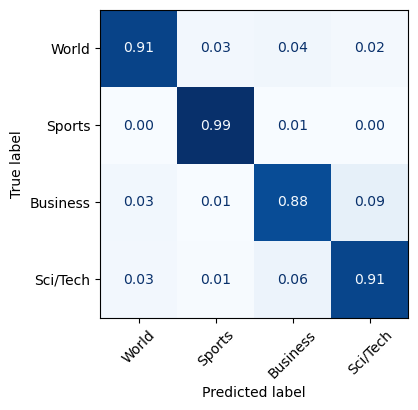

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(cmap='Blues', values_format='.2f', colorbar=False, ax=ax, xticks_rotation=45)

Retrieving Notebook summary.

Read output of [](vscode-notebook-cell:/Users/jepo7247/Downloads/marco-gentil-DL-book/marco-GentleNLP/v3.1-chap07_ffnn.ipynb#X52sZmlsZQ%3D%3D)

Ran [](vscode-notebook-cell:/Users/jepo7247/Downloads/marco-gentil-DL-book/marco-GentleNLP/v3.1-chap07_ffnn.ipynb#X52sZmlsZQ%3D%3D)

The results in Cell 39 show a **Classification Report**, which is a comprehensive evaluation of your model's performance on the test set.

### Defining Key Metrics

1.  **Precision** (Quality):
    *   **Question**: "Of all the articles the model *guessed* were Sports, how many were actually Sports?"
    *   **Meaning**: It measures how accurate the positive predictions are. A high precision means the model doesn't make many "false alarms" (predicting a category when it's not there).
    *   **Formula**: $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

2.  **Recall** (Quantity):
    *   **Question**: "Of all the *actual* Sports articles that exist, how many did the model find?"
    *   **Meaning**: It measures the model's ability to find all relevant cases. A high recall means the model doesn't "miss" many articles that actually belong to that category.
    *   **Formula**: $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

### Explaining Your Specific Results
Based on your output in Cell 39:

*   **Overall Accuracy (0.92)**: Your model correctly classified 92% of the 7,600 news articles. This is a very strong result for a simple Bag of Words model!
*   **Best Performer (Sports)**: With a **Recall of 0.99** and **Precision of 0.96**, the model is nearly perfect at identifying sports news. Sports articles often use very specific vocabulary (e.g., "score," "match," "team"), making them easy for a BOW model to pick up.
*   **Hardest Categories (Business & Sci/Tech)**: These have slightly lower F1-scores (0.89 and 0.90). This is common because business and technology articles often share similar words (e.g., "company," "market," "profit," "software"), leading to more confusion between the two.
*   **F1-Score**: This is the harmonic mean of Precision and Recall. Since your Precision and Recall are very balanced (around 0.92 macro avg), the F1-score confirms your model hasn't biased one over the other.